In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

Датасет болезней сердца содержит информацию о пациентах и переменную предсказания target — наличие у пациента болезни сердца.

Датасет содержит следующие признаки:

* age — возраст
* sex — пол (1 - мужчина, 0 - женщина)
* cp — тип боли в груди (4 значения)
* trestbps — артериальное давление в покое
* chol — холестерин сыворотки в мг/дл
* fbs — уровень сахара в крови натощак > 120 мг/дл
* restecg — результаты электрокардиографии в покое (значения 0,1,2)
* thalach — достигнута максимальная частота сердечных сокращений
* exang — стенокардия, вызванная физической нагрузкой
* oldpeak — депрессия ST, вызванная физической нагрузкой, по сравнению с состоянием покоя
* slope — наклон пикового сегмента ST при нагрузке
* ca — количество крупных сосудов (0-3), окрашенных при флюроскопии
* thal — дефект, где 3 = нормальный; 6 = фиксированный дефект; 7 = обратимый дефект

In [2]:
data = pd.read_csv('data/heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Задание 8.1

Создайте новый признак old, где 1 — при возрасте пациента более 60 лет.

В ответ введите результат выполнения кода heart['old'].sum().

In [3]:
data['old'] = data['age'].apply(lambda x: 1 if x > 60 else 0)

In [4]:
data['old'].sum()

79

### Задание 8.2

Создайте новый признак trestbps_mean, который будет обозначать норму давления в среднем для его возраста и пола. trestbps — систолическое артериальное давление в состоянии покоя.

Информацию о среднем давлении для возраста и пола возьмите из этой таблицы. В таблице систолическое давление написано первым, перед дробной чертой.

In [5]:
conditions = [
    (data['age'] <= 20),
    (data['age'] > 20) & (data['age'] <= 30),
    (data['age'] > 30) & (data['age'] <= 40),
    (data['age'] > 40) & (data['age'] <= 50),
    (data['age'] > 50) & (data['age'] <= 60),
    (data['age'] > 60)
]

trestbps_male = [123, 126, 129, 135, 142, 142]
trestbps_female = [116, 120, 127, 137, 144, 159]

data['trestbps_mean'] = np.select(conditions, [np.where(data['sex'] == 1, choice, choice_f) 
                                             for choice, choice_f in zip(trestbps_male
                                            , trestbps_female)])


In [6]:
data['trestbps_mean'][300]

142

In [7]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,old,trestbps_mean
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,1,142
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,0,129
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0,137
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,0,142
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,0,144


### Задание 8.5

Закодируйте вышеперечисленные признаки методом OneHotEncoding из библиотеки Category Encoders, удалив исходные признаки. Параметр use_cat_names оставьте по умолчанию.

Сколько признаков получилось в датасете?

In [8]:
#Закадируем признак 'cp' и удалим исходный
encoder = ce.OneHotEncoder(cols=['cp'])
cp_bin = encoder.fit_transform(data['cp'])
data = pd.concat([data, cp_bin], axis=1)
data = data.drop(['cp'], axis=1)

c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: Futur

In [9]:
#Закадируем признак 'restecg' и удалим исходный
encoder = ce.OneHotEncoder(cols=['restecg'])
cp_bin = encoder.fit_transform(data['restecg'])
data = pd.concat([data, cp_bin], axis=1)
data = data.drop(['restecg'], axis=1)

c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: Futur

In [10]:
#Закадируем признак 'slope' и удалим исходный
encoder = ce.OneHotEncoder(cols=['slope'])
cp_bin = encoder.fit_transform(data['slope'])
data = pd.concat([data, cp_bin], axis=1)
data = data.drop(['slope'], axis=1)

c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: Futur

In [11]:
#Закадируем признак 'ca' и удалим исходный
encoder = ce.OneHotEncoder(cols=['ca'])
cp_bin = encoder.fit_transform(data['ca'])
data = pd.concat([data, cp_bin], axis=1)
data = data.drop(['ca'], axis=1)

c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: Futur

In [12]:
#Закадируем признак 'thal' и удалим исходный
encoder = ce.OneHotEncoder(cols=['thal'])
cp_bin = encoder.fit_transform(data['thal'])
data = pd.concat([data, cp_bin], axis=1)
data = data.drop(['thal'], axis=1)

c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
c:\Users\Zylno\AppData\Local\Programs\Python\Python311\Lib\site-packages\category_encoders\ordinal.py:198: Futur

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    int64  
 1   sex            303 non-null    int64  
 2   trestbps       303 non-null    int64  
 3   chol           303 non-null    int64  
 4   fbs            303 non-null    int64  
 5   thalach        303 non-null    int64  
 6   exang          303 non-null    int64  
 7   oldpeak        303 non-null    float64
 8   target         303 non-null    int64  
 9   old            303 non-null    int64  
 10  trestbps_mean  303 non-null    int32  
 11  cp_1           303 non-null    int64  
 12  cp_2           303 non-null    int64  
 13  cp_3           303 non-null    int64  
 14  cp_4           303 non-null    int64  
 15  restecg_1      303 non-null    int64  
 16  restecg_2      303 non-null    int64  
 17  restecg_3      303 non-null    int64  
 18  slope_1   

### Задание 8.6

Нормализуйте все числовые признаки подходящим способом.

В ответе напишите стандартное отклонение признака chol. Ответ округлите до шести знаков после запятой.

In [22]:
display(data)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,old,...,slope_3,ca_1,ca_2,ca_3,ca_4,ca_5,thal_1,thal_2,thal_3,thal_4
0,0.592593,1.0,0.75,-0.110236,1.0,-0.092308,0.0,2.3,1,1,...,0,1,0,0,0,0,1,0,0,0
1,-1.333333,1.0,0.00,0.157480,0.0,1.046154,0.0,3.5,1,0,...,0,1,0,0,0,0,0,1,0,0
2,-1.037037,0.0,0.00,-0.566929,0.0,0.584615,0.0,1.4,1,0,...,0,1,0,0,0,0,0,1,0,0
3,0.074074,1.0,-0.50,-0.062992,0.0,0.769231,0.0,0.8,1,0,...,0,1,0,0,0,0,0,1,0,0
4,0.148148,0.0,-0.50,1.795276,0.0,0.307692,1.0,0.6,1,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.148148,0.0,0.50,0.015748,0.0,-0.923077,1.0,0.2,0,0,...,1,1,0,0,0,0,0,0,1,0
299,-0.740741,1.0,-1.00,0.377953,0.0,-0.646154,0.0,1.2,0,0,...,1,1,0,0,0,0,0,0,1,0
300,0.962963,1.0,0.70,-0.740157,1.0,-0.369231,0.0,3.4,0,1,...,1,0,1,0,0,0,0,0,1,0
301,0.148148,1.0,0.00,-1.716535,0.0,-1.169231,1.0,1.2,0,0,...,1,0,0,1,0,0,0,0,1,0


In [17]:
r_scaler = preprocessing.RobustScaler()
data[['age', 'trestbps', 'chol', 'thalach']] = r_scaler.fit_transform(data[['age', 'trestbps', 'chol', 'thalach']])

In [20]:
mm_scaler = preprocessing.MinMaxScaler()
data[['sex', 'fbs', 'exang', 'restecg_1', 'restecg_2']] = mm_scaler.fit_transform(data[['sex', 'fbs', 'exang', 'restecg_1', 'restecg_2']])

In [18]:
round(data['chol'].std(), 6)

0.816232

### Задание 8.7

Проведите корреляционный анализ и отберите признаки для будущей модели. Выберите пары сильно скоррелированных признаков.

<Axes: >

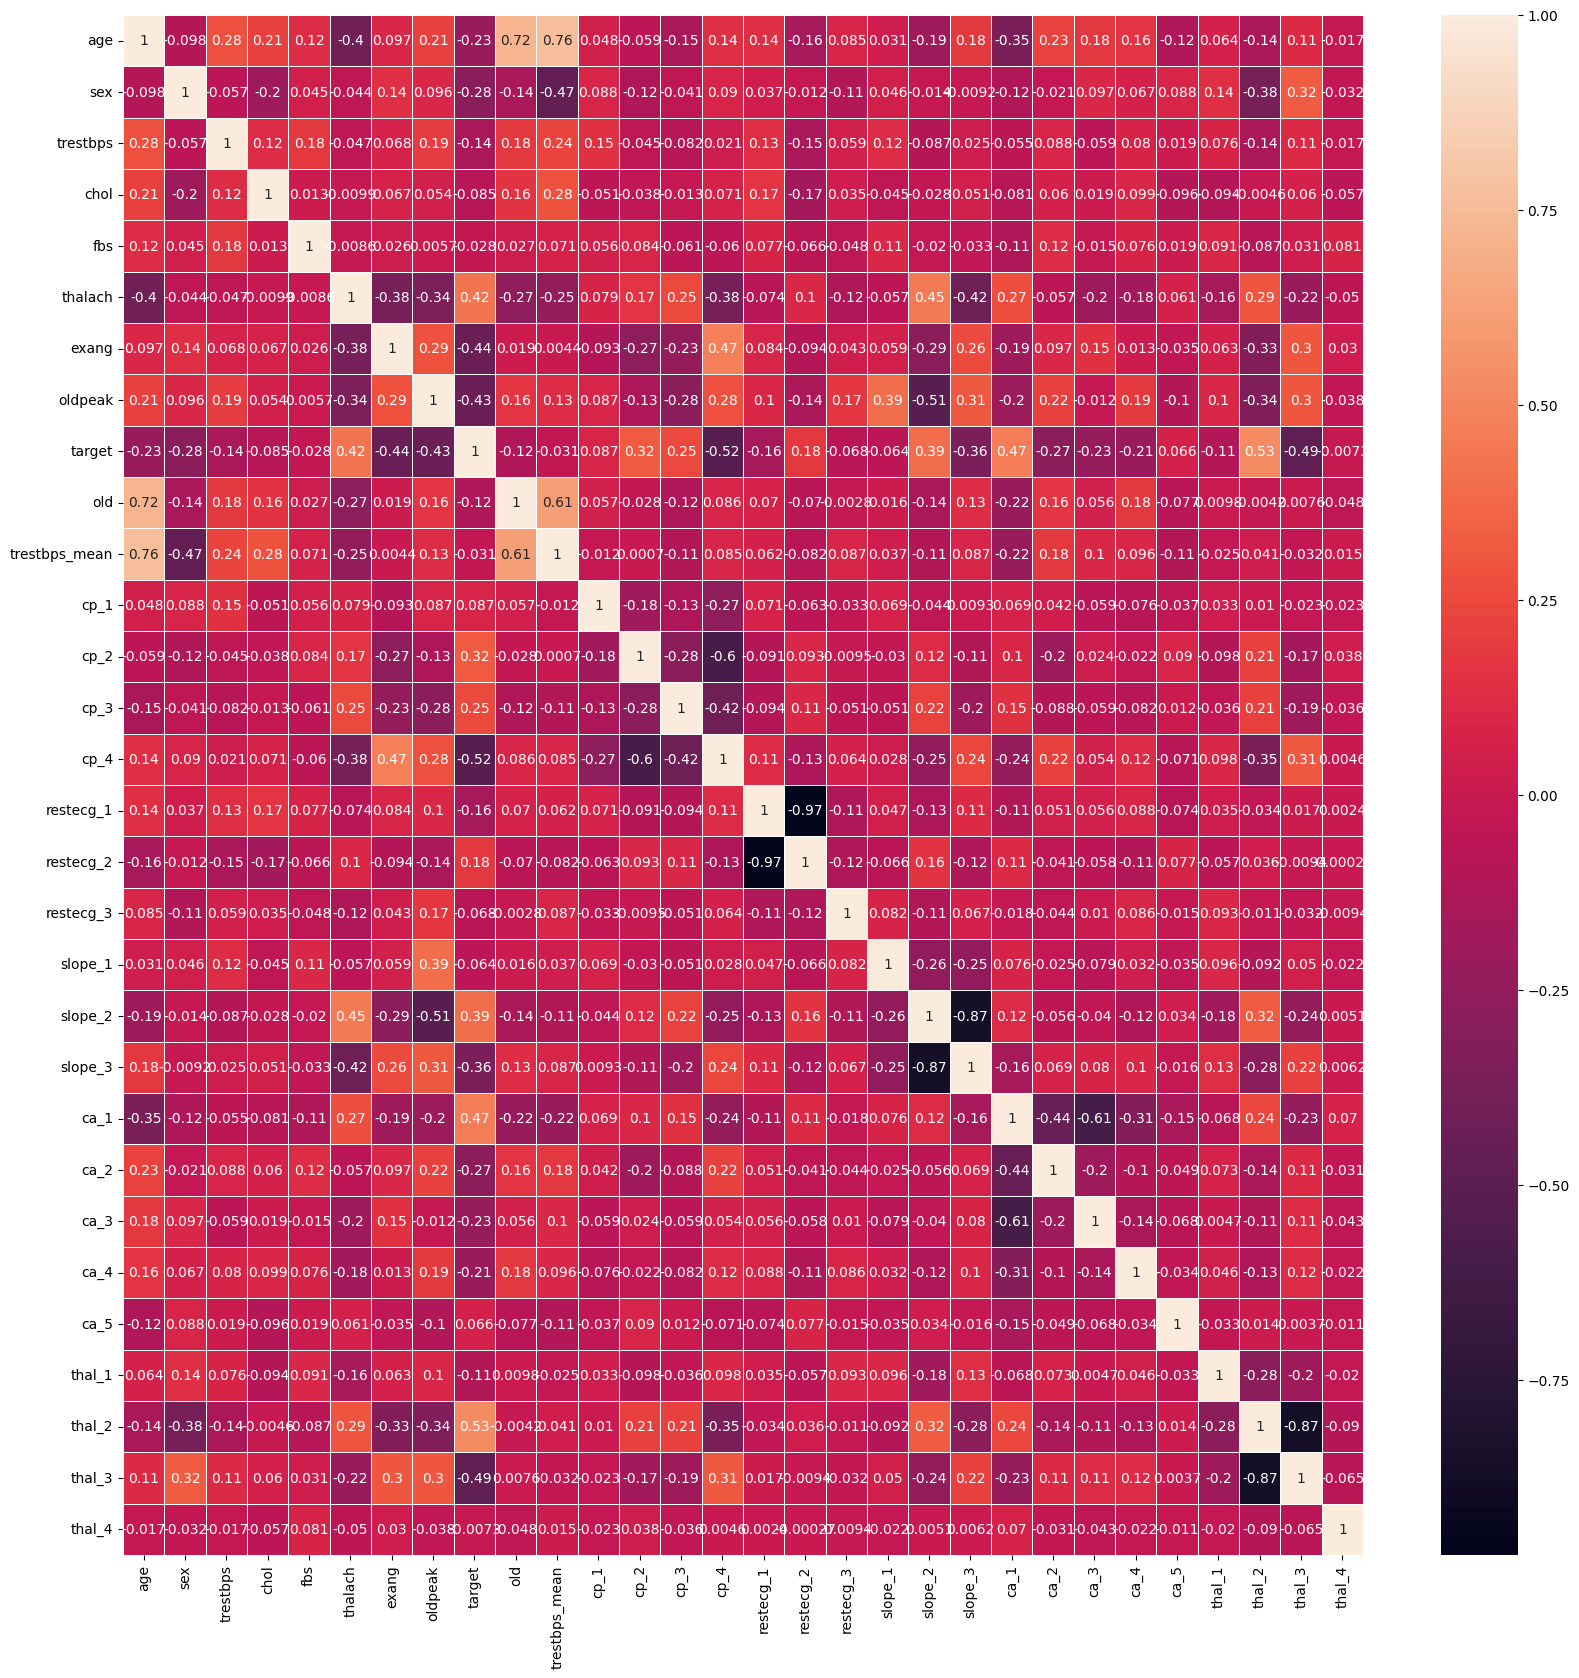

In [21]:
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidths=.5, ax=ax)